# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 1   |  |
| :-------------|:-------------|
|Meike Ligtenberg| 6242545 |
| Pepper van Berkum| 6525512 |
| Ebe Polman| 6581455 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Meike', 'Pepper','Ebe']

## Opdracht 1: Planning.

| Planning Groep: 1     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibratie af| 11.30 |
| Testen meetopstelling | 12.00 |
| Algoritme bedenken| 13.45 |
|Iteratie 0 | 14.30 | 
| Iteraties | 16.30 |
| Algoritme aan TA laten zien| 16.30|
| groep aanwezig 2| Tijdspanne |
| Pauze 1| 12.30 - 13.30 |


## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [nummer]
<img src="tudelftLogo.png" width="400">

[0.03435336 0.14967466]


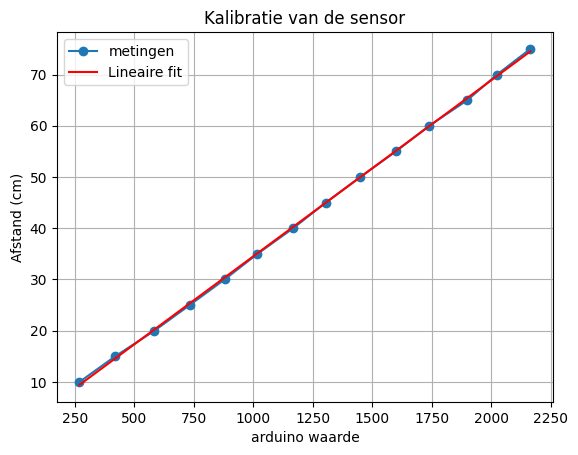

In [3]:
# verwerk hier jullie kalibratiemetingen
from scipy.optimize import curve_fit

afstanden = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75])
arduino_waarden = np.array([270, 420, 585, 733, 880, 1018, 1168, 1305, 1450, 1600, 1740, 1900, 2025, 2165])

def lineair(x, a, b):
    return a * x + b

a, b = curve_fit(lineair, arduino_waarden, afstanden)

print(a)

plt.figure()
plt.plot(arduino_waarden, afstanden, label = 'metingen', marker='o')
plt.plot(arduino_waarden, lineair(arduino_waarden, a[0], a[1]), label='Lineaire fit', color='red')
plt.xlabel('arduino waarde')
plt.ylabel('Afstand (cm)')
plt.title('Kalibratie van de sensor')
plt.legend()
plt.grid()
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  40   0  30  41
1   0  30   0  20  40
2  40   0  30   0  41
3  30   0  20   0  41


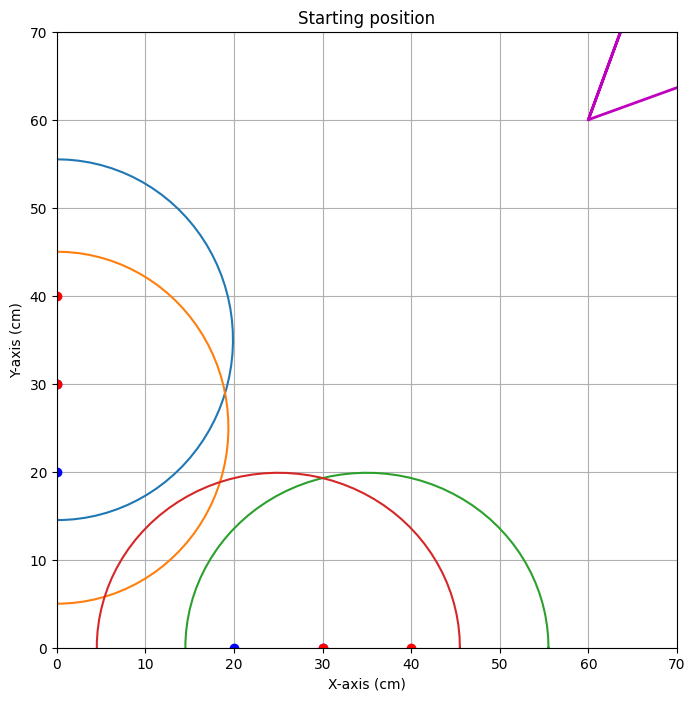


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.205


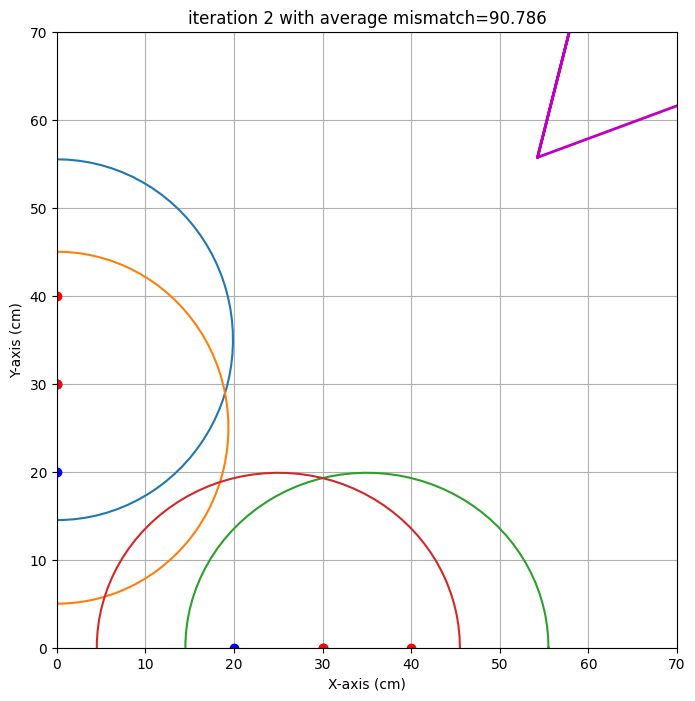

end iteration 2 with average mismatch=90.786


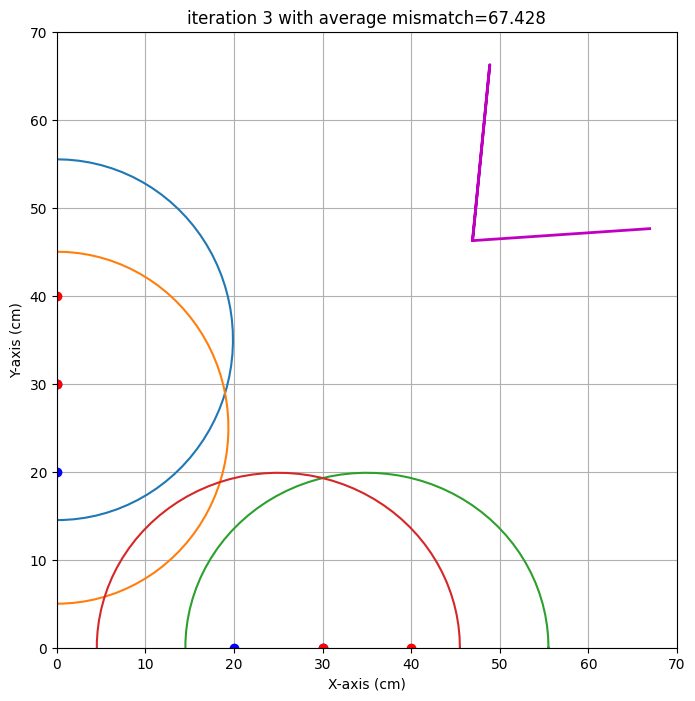

end iteration 3 with average mismatch=67.428


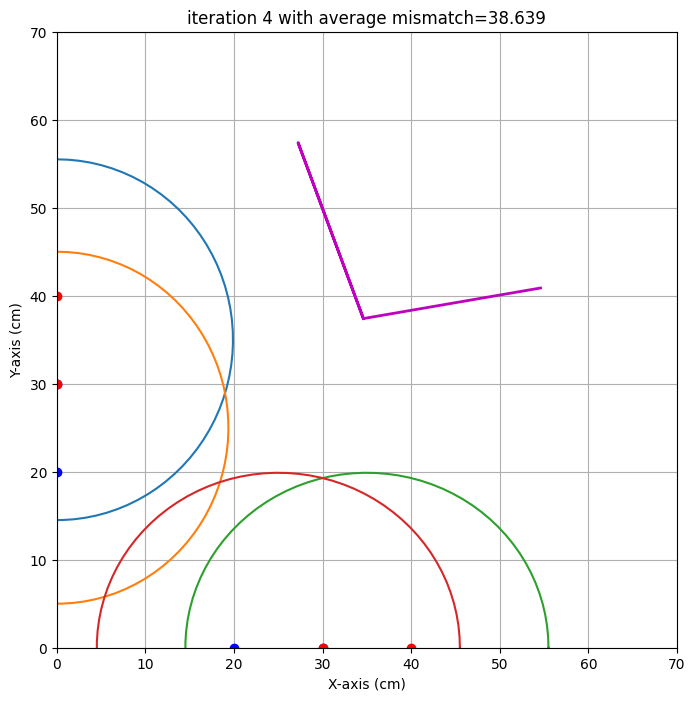

end iteration 4 with average mismatch=38.639


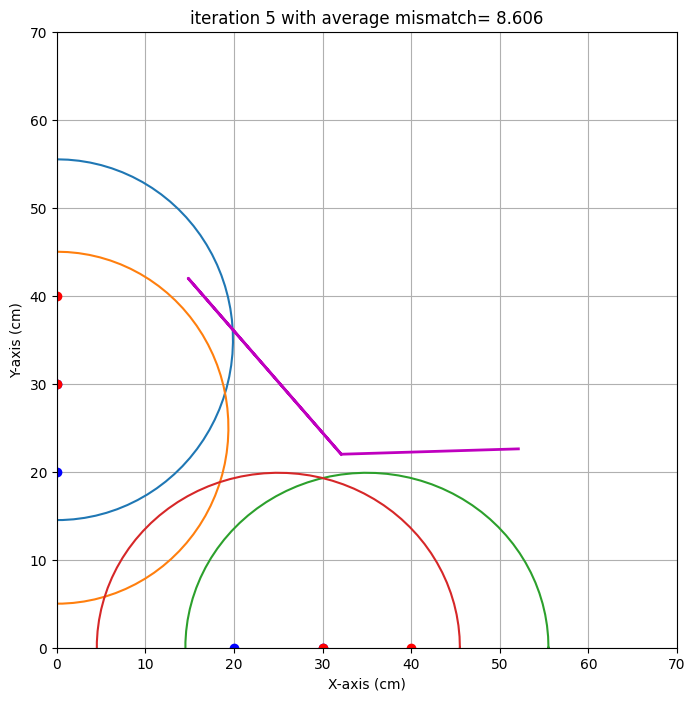

end iteration 5 with average mismatch= 8.606


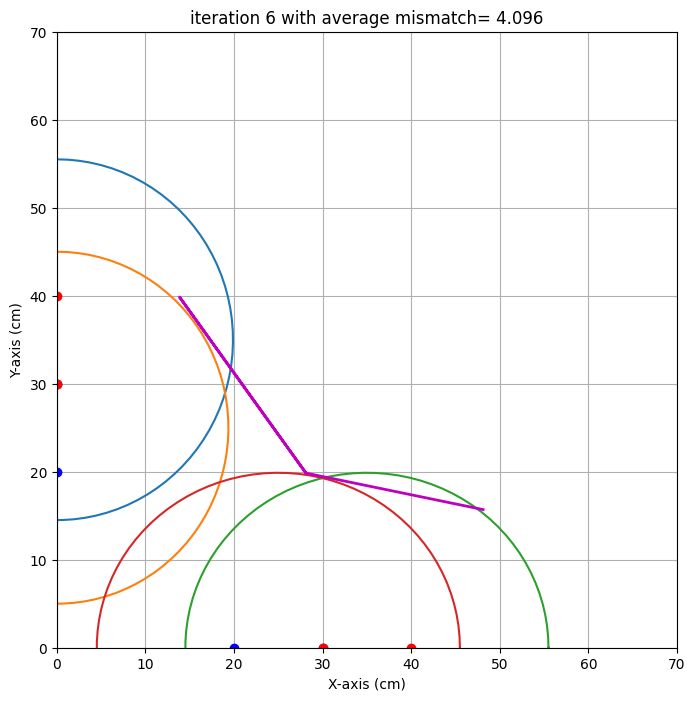

end iteration 6 with average mismatch= 4.096


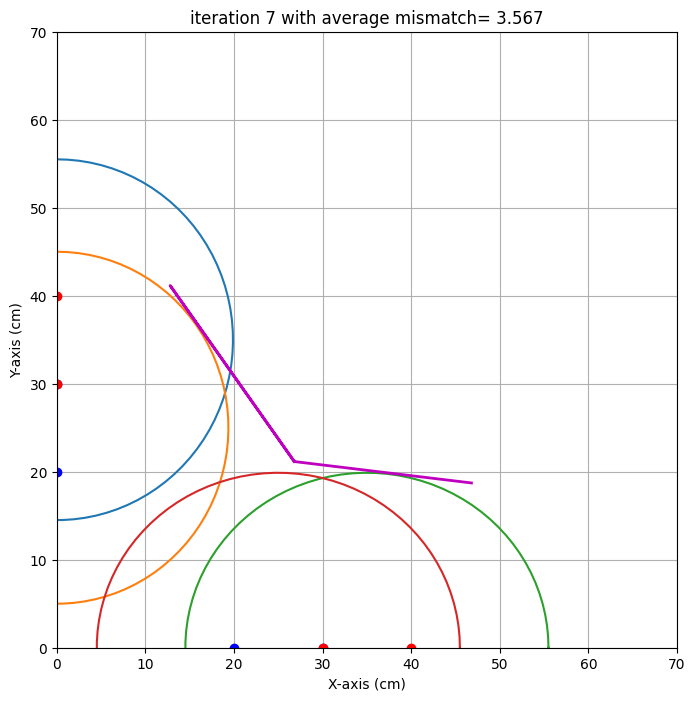

end iteration 7 with average mismatch= 3.567


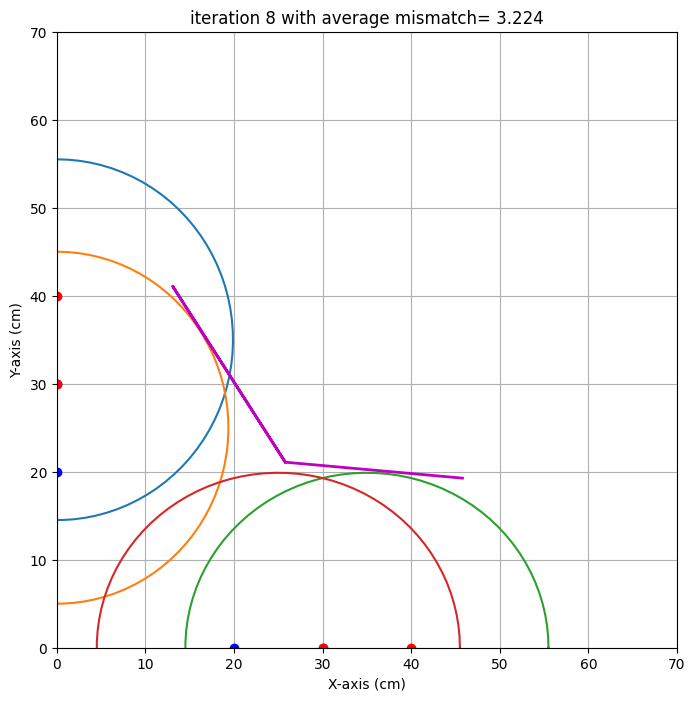

end iteration 8 with average mismatch= 3.224


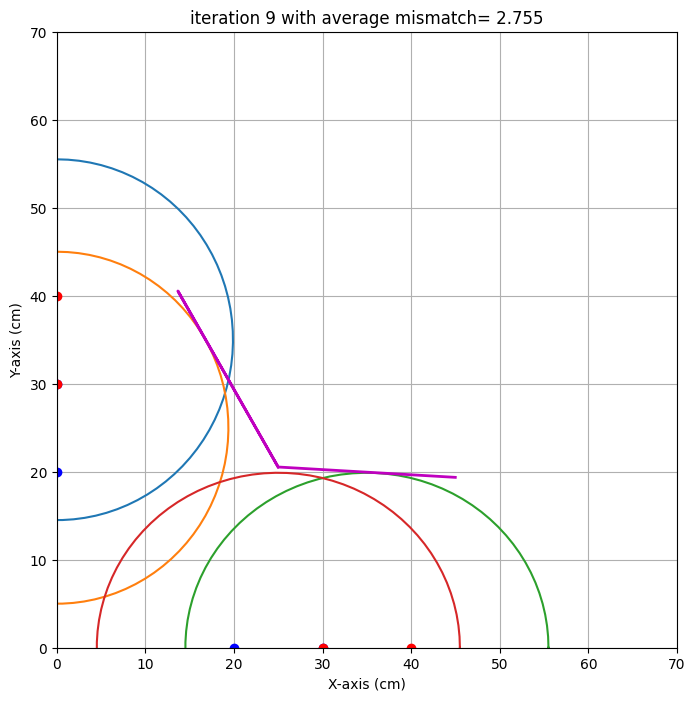

end iteration 9 with average mismatch= 2.755
end iteration 10 with average mismatch= 2.711
end iteration 11 with average mismatch= 2.708
end iteration 12 with average mismatch= 2.708
end iteration 13 with average mismatch= 2.707
end iteration 14 with average mismatch= 2.698


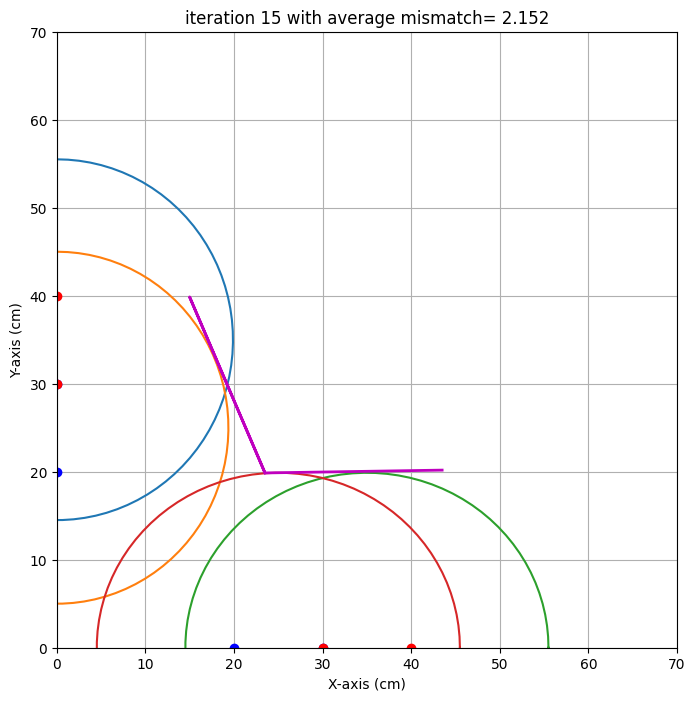

end iteration 15 with average mismatch= 2.152
end iteration 16 with average mismatch= 2.089


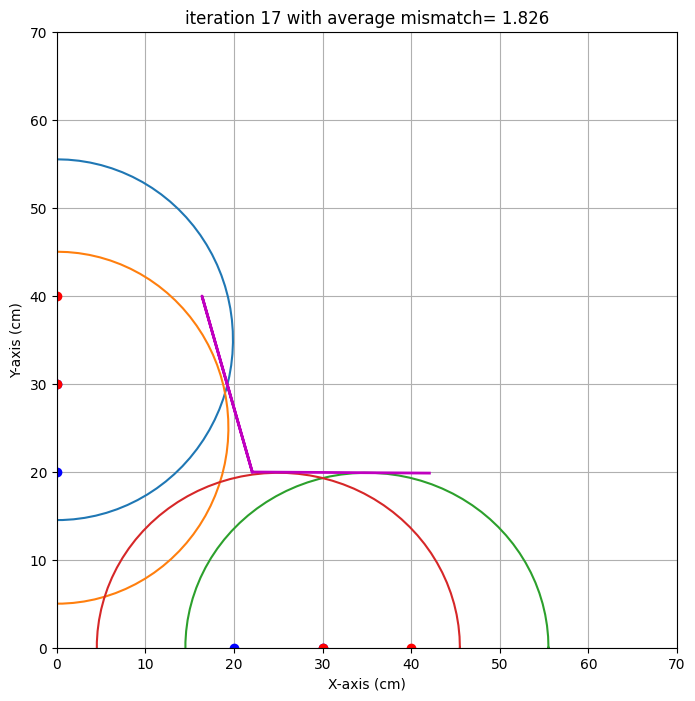

end iteration 17 with average mismatch= 1.826
end iteration 18 with average mismatch= 1.818
end iteration 19 with average mismatch= 1.818
end iteration 20 with average mismatch= 1.818
end iteration 21 with average mismatch= 1.818
end iteration 22 with average mismatch= 1.719


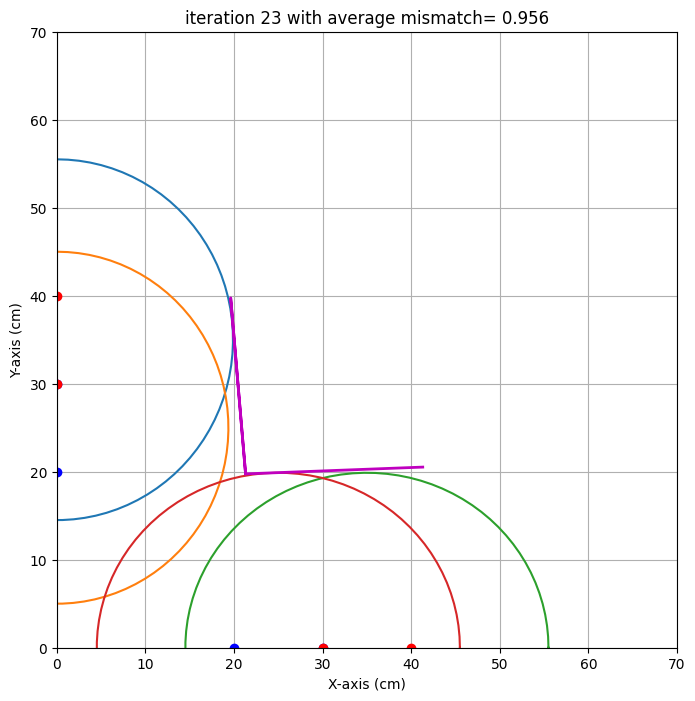

end iteration 23 with average mismatch= 0.956


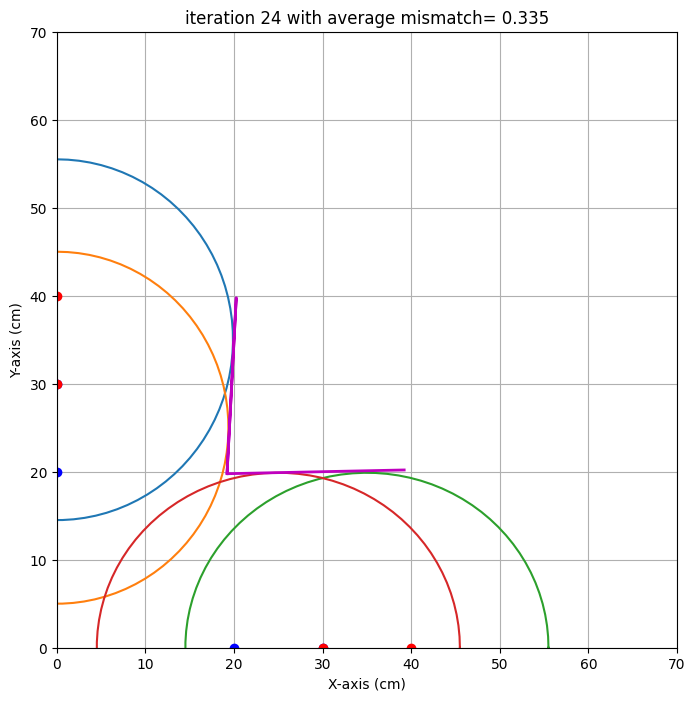

end iteration 24 with average mismatch= 0.335
end iteration 25 with average mismatch= 0.316
end iteration 26 with average mismatch= 0.314
end iteration 27 with average mismatch= 0.313


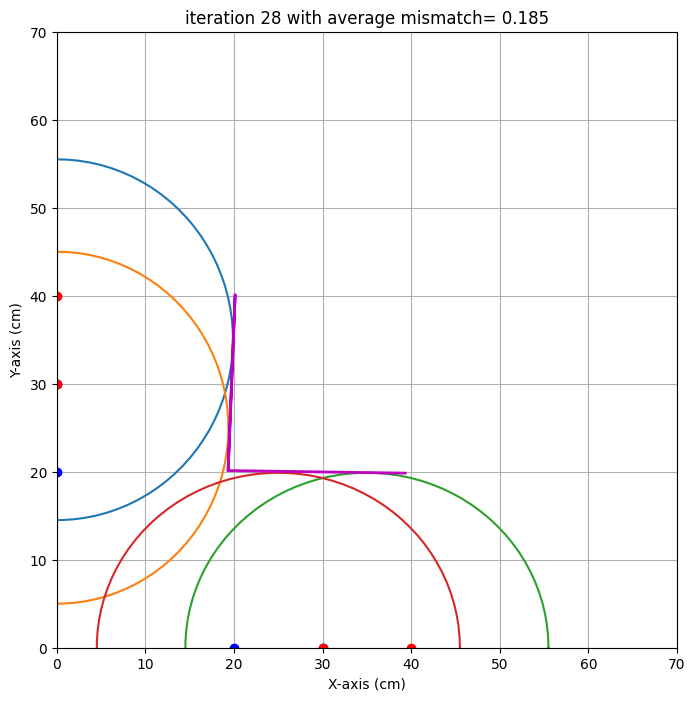

end iteration 28 with average mismatch= 0.185


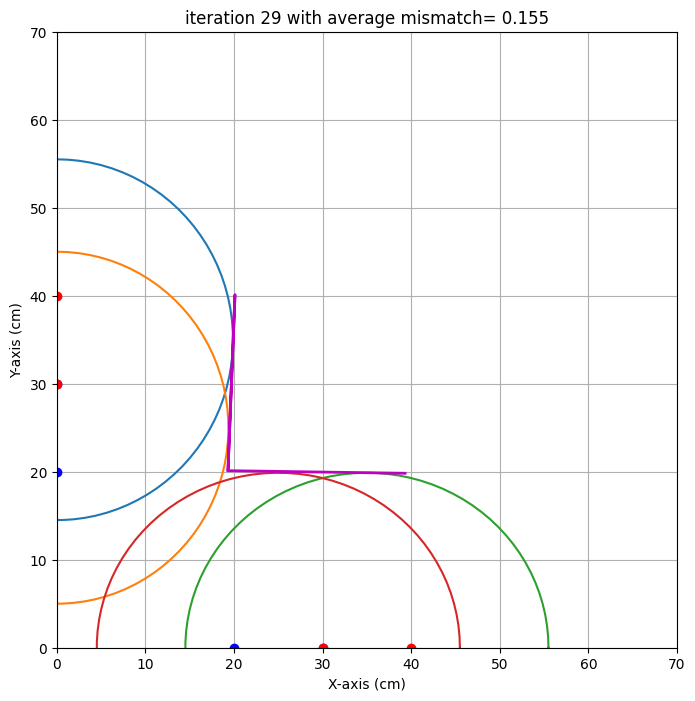

end iteration 29 with average mismatch= 0.155
Last iteration, also determine uncertainty, wait a while..
wait a little longer....


In [ ]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41],
    [0,30,0,20,40],
    #[0,10,0,20,160],
    [40,0,30,0,41],
    [30,0,20,0,41],
    #[10,0,20,0,170],
    #[10,0,0,10,160]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [ ]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

In [ ]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,45,0,30,83],
    [10,0,0,10,104],
    #[0,45,0,70,160],
    #[0,55,0,70,160],
    [0,65,0,70,90],
    #[10,0,20,0,170],
    #[10,0,0,10,160]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

## Opdracht 5: Iteratie 0

#### algoritme [Meike]

<img src="algoritme_meike.jpeg" width="400">

#### algoritme [Pepper]
<img src="algoritme_pepper.jpeg" width="400">

#### algoritme [Ebe]
<img src="algoritme_ebe_goede.jpeg" width="400">

Als de afstand groter is dan 160 cm dan is de meting ongeldig.
Daarnaast moet de scherpe hoek naar de oorsprong gericht staan.

In [ ]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 37.1,  
           'y0':41.2,
           'alpha' : 13,
           'beta' : 13,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={ 'Meike' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,90],
    #[0,40, 0,50, 160],
    #[0,0,10,0, 160],
    [50,0,60,0, 80],
    ]),
       'Pepper' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45,0,60,0,88.5],
    [55,0,70,0,93],
    #[40,0,20,0,160],
    #[25,0,5,0, 160]
    ]),
       'Ebe' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[10,0,20,0,160],
    [40,0,50,0, 86],
    [50,0,60,0, 89],
    #[0,20,0,10, 160],
    [0,50,0,40,80],
    [0,60,0,50,78]
    ])
      }

## Opdracht 7: Evaluatie.

In [ ]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [ ]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](algoritme_eerste_iteratie.jpeg)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 33.5,
                    'y0':49,
                    'alpha' : 14,
                    'beta' : 7},
           'locatie 2':{'x0': 45.2,
                    'y0': 45.8,
                    'alpha' : 15,
                    'beta' : 14}
            }

           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.



# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,90],
    [50,0,60,0, 95],
    [30,0,40,0, 98],
    [0,40,0,50,69],
    [0,60,0,70,63],
    [0,50,0,60, 65.5]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[40,0,50,0,160],
    #[0,0,10,0,160],
    #[50,0,60,0, 97],
    [60,0,70,0,100],
    #[0,40,0,50, 160],
    #[0,0,0,10, 160],
    [0,50,0,60, 96.5],
    [0,60,0,70,98]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 34.2,
                    'y0': 40,
                    'alpha' : 14, 
                    'beta' : -11 
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [40,0,50,0,86],
                    [0,40,0,50, 66.5],
                    [0,50,0,60,62.5],
                    #[0,60,0,70, 160],
                    [50,0,60,0, 90.6],
                    # [30,0,40,0, 160]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Leerdoel 1: Inzien dat het maken van een algoritme een ontwerpproces.

Figuur: ![Alt](algoritme_meike.jpeg "0e iteratie")
bij de eerste schetsen van algoritmes waren er nog een paar problemen, zoals oneindig doorlopende schemas en als het begon met een geldige keuze op de x as, het algoritme niet verder ging naar de y-as.

Figuur: ![Alt](algoritme_eerste_iteratie.jpeg "1e iteratie")

ten opzichte van het eerst algoritme is er hier toegevoegd dat er in stapjes van 10cm wordt gewerkt. Ook zijn er stops toegevoegd en paden uitgebreid die eerst vroegtijdig eindigden. 

Figuur: ![Alt](uiteindelijke_algoritme.jpeg "Uiteindelijke algoritme")
We zagen dat een ellips soms de punt raakt, waardoor de meting ongeldig moest worden. Dus dit hebben we aan het algoritme toegevoegd.

Leerdoel 2: De ontwerpcyclus optimaal inrichten op de randvoorwaarden van de ontwerpopdracht.

Figuur: ![Alt](algoritme_meike.jpeg "0e iteratie")
bij de eerste schetsen van algoritmes waren er nog een paar problemen, zoals oneindig doorlopende schemas en als het begon met een geldige keuze op de x as, het algoritme niet verder ging naar de y-as.

Figuur: ![Alt](algoritme_eerste_iteratie.jpeg "1e iteratie")

ten opzichte van het eerst algoritme is er hier toegevoegd dat er in stapjes van 10cm wordt gewerkt. Ook zijn er stops toegevoegd en paden uitgebreid die eerst vroegtijdig eindigden. 

Figuur: ![Alt](uiteindelijke_algoritme.jpeg "Uiteindelijke algoritme")
We zagen dat een ellips soms de punt raakt, waardoor de meting ongeldig moest worden. Dus dit hebben we aan het algoritme toegevoegd.


Onderstaande code is ook om te laten zien dat we leerdoel 2 gehaald hebben.

In [ ]:
# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 34.2,
                    'y0': 40,
                    'alpha' : 14, 
                    'beta' : -11 
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [40,0,50,0,86],
                    [0,40,0,50, 66.5],
                    [0,50,0,60,62.5],
                    #[0,60,0,70, 160],
                    [50,0,60,0, 90.6],
                    # [30,0,40,0, 160]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))